# Physique des marchés
## TP3.2 : Gain et impact de marché

### Par : Adonis JAMAL

#### Buts

1. Etudier le gain de catégories d'investisseurs
2. Etudier l'impact de la mémoire sur le comportement des agents

Reprendre le code du TP3.1 pour le jeu de la minorité à nombre de spéculateurs variable.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import powerlaw
from tqdm import tqdm

np.random.seed(18)

In [2]:
@njit
def _run_simulation(a, Omega, U, mu, P, epsilon, T):
    A_history = np.empty(T)
    for t in range(T):
        n = (U >= 0).astype(np.float64)
        A_t = Omega[mu] + np.sum(n * a[:, mu])
        A_history[t] = A_t
        U -= a[:, mu] * A_t + epsilon
        mu = (2 * mu + int(A_t > 0)) % P
    return A_history, U, mu

@njit
def _run_detailed(a, Omega, U, mu, P, epsilon, T):
    """Simulation retournant aussi phi_i et g_i par agent."""
    N_s = a.shape[0]
    A_hist = np.empty(T)
    phi = np.zeros(N_s)
    gain = np.zeros(N_s)
    for t in range(T):
        n = (U >= 0).astype(np.float64)
        A_t = Omega[mu] + np.sum(n * a[:, mu])
        A_hist[t] = A_t
        phi += n
        gain -= n * a[:, mu] * A_t
        U -= a[:, mu] * A_t + epsilon
        mu = (2 * mu + int(A_t > 0)) % P
    phi /= T
    gain /= T
    return A_hist, U, mu, phi, gain

---
### 1. Fréquence du jeu et impact

Choisir des paramètres pour lesquels la dynamique de $A(t)$, dans l’état stationnaire, est stable (pas de grandes fluctuations relatives).

Dans l’état stationnaire,

1. Calculer la fréquence d'activité $\phi_i$ de chaque spéculateur

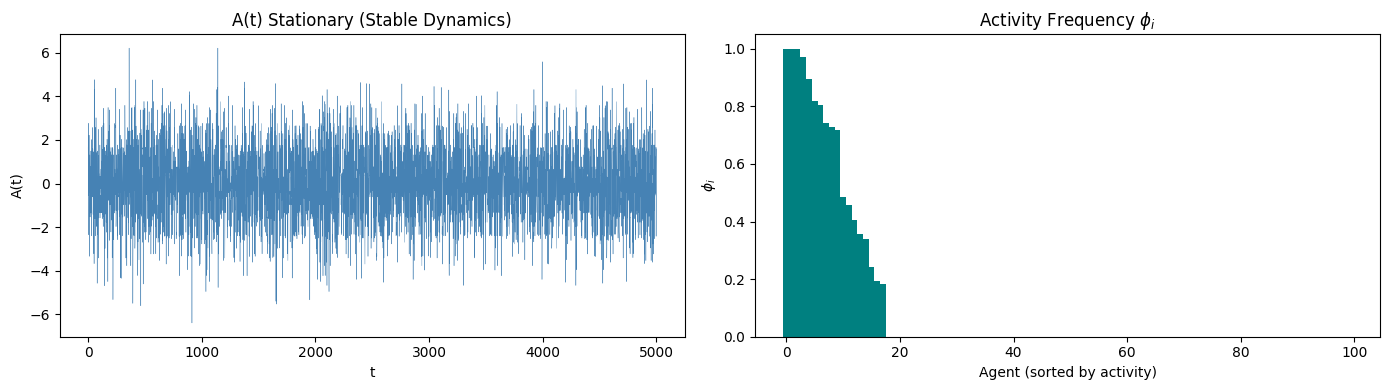

In [3]:
# Parameters
P = 16
N_p = P
N_s = 100
epsilon = 0.01
T_phase = int(200 * P / epsilon)

Omega = np.random.normal(0, np.sqrt(N_p), size=P)
a = np.random.choice([-1, 1], size=(N_s, P)).astype(np.float64)
U = np.zeros(N_s)
mu = np.random.randint(0, P)

_, U, mu = _run_simulation(a, Omega, U, mu, P, epsilon, T_phase)
A_meas, U, mu, phi, gain = _run_detailed(a, Omega, U, mu, P, epsilon, T_phase)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(A_meas[:5000], linewidth=0.3, color='steelblue')
axes[0].set_xlabel('t')
axes[0].set_ylabel('A(t)')
axes[0].set_title("A(t) Stationary (Stable Dynamics)")

order = np.argsort(phi)[::-1]
axes[1].bar(range(N_s), phi[order], width=1.0, color='teal')
axes[1].set_xlabel("Agents (sorted by activity)")
axes[1].set_ylabel(r'$\phi_i$')
axes[1].set_title(r"Activity Frequency $\phi_i$")
plt.tight_layout()
plt.show()

2. Calculer le gain moyen de chaque spéculateur $g_i$

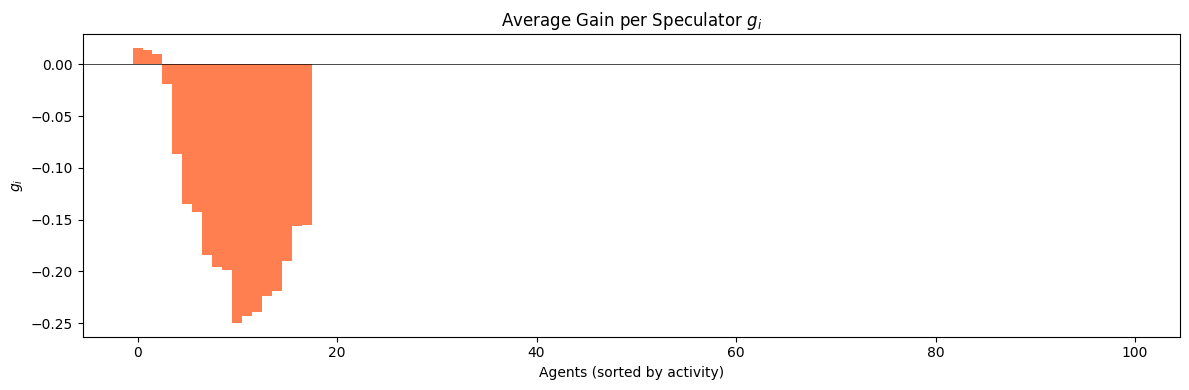

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(N_s), gain[order], width=1.0, color='coral')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel("Agents (sorted by activity)")
ax.set_ylabel(r'$g_i$')
ax.set_title("Average Gain per Speculator $g_i$")
plt.tight_layout()
plt.show()

3. Tracer le gain moyen de chaque spéculateur en fonction de sa fréquence d'activité. Commenter.

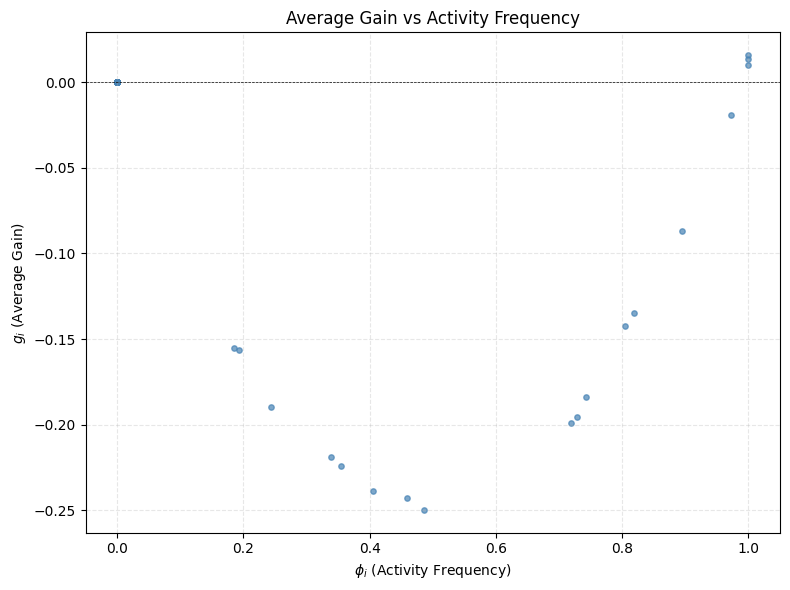

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(phi, gain, s=15, alpha=0.7, color='steelblue')
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.set_xlabel(r"$\phi_i$ (Activity Frequency)")
ax.set_ylabel(r"$g_i$ (Average Gain)")
ax.set_title("Average Gain vs Activity Frequency")
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

<blockquote>

The relationship between $g_i$ and $\phi_i$ is non-monotonic. Agents with $\phi_i = 0$ have $g_i = 0$ (they never trade). Agents with $\phi_i \approx 1$ (permanently active, "frozen" agents) have small positive gains: their strategies are well-adapted to the market and remain validated over time, allowing them to extract predictability from the producers. Agents with intermediate activity ($\phi_i \in [0.3, 0.5]$) suffer the largest losses ($g_i \approx -0.25$). These agents oscillate between active and inactive states; when they re-enter the market, they tend to crowd on the same side as other re-entering agents, amplifying $|A(t)|$ and landing in the majority. This is the overcrowding effect of the minority game: intermittent participants collectively worsen market efficiency and pay the cost.

</blockquote>

---
### 2. Faits Stylisés et mémoire finie

Considérons un MG avec nombre variable de spéculateurs actifs.

1. Introduisez une mémoire finie dans la mise à jour de $U_i(t)$, encodée par $\lambda > 0$ (voir cours). Pour des valeurs bien choisies de paramètres, tracer la densité de $A(t)$ dans l’état stationnaire. En réutilisant votre code du TP1, déterminer si $P(|A|)$ a une queue lourde et si oui la nature de cette dernière.

 25%|██▌       | 1/4 [00:10<00:30, 10.28s/it]

lam=0.0: alpha=2.404, xmin=0.75
  PL vs Exp: R=-132.014, p=0.000 | PL vs LN: R=-117.980, p=0.000


 50%|█████     | 2/4 [00:41<00:44, 22.30s/it]

lam=0.005: alpha=1.895, xmin=2.65
  PL vs Exp: R=224.602, p=0.000 | PL vs LN: R=-33.043, p=0.000


 75%|███████▌  | 3/4 [01:30<00:34, 34.76s/it]

lam=0.02: alpha=2.253, xmin=8.85
  PL vs Exp: R=54.398, p=0.000 | PL vs LN: R=-40.744, p=0.000


100%|██████████| 4/4 [01:33<00:00, 23.47s/it]

lam=0.1: alpha=1.683, xmin=4.35
  PL vs Exp: R=157.873, p=0.000 | PL vs LN: R=-19.948, p=0.000


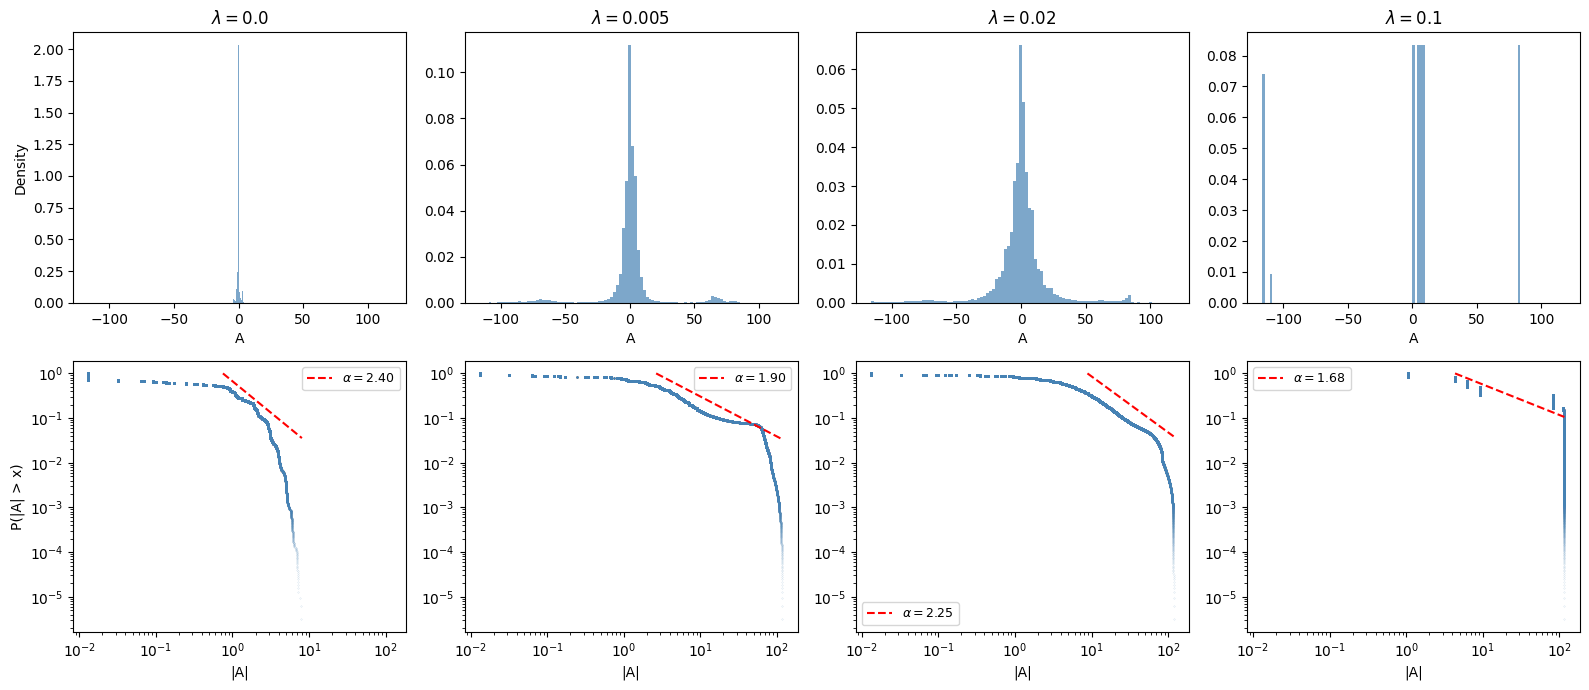

In [35]:
@njit
def _run_finite_memory(a, Omega, U, mu, P, epsilon, lam, T):
    A_hist = np.empty(T)
    for t in range(T):
        n = (U >= 0).astype(np.float64)
        A_t = Omega[mu] + np.sum(n * a[:, mu])
        A_hist[t] = A_t
        U[:] = (1 - lam) * U - a[:, mu] * A_t - epsilon
        mu = (2 * mu + int(A_t > 0)) % P
    return A_hist, U, mu

P, N_p, N_s, epsilon = 16, 16, 200, 0.01
T_phase = int(200 * P / epsilon)
lambdas = [0.0, 0.005, 0.02, 0.1]

fig, axes = plt.subplots(2, len(lambdas), figsize=(16, 7), sharex='row')

for j, lam in tqdm(enumerate(lambdas), total=len(lambdas)):
    np.random.seed(42)
    Omega = np.random.normal(0, np.sqrt(N_p), size=P)
    a = np.random.choice([-1, 1], size=(N_s, P)).astype(np.float64)
    U = np.zeros(N_s)
    mu = np.random.randint(0, P)

    _, U, mu = _run_finite_memory(a, Omega, U, mu, P, epsilon, lam, T_phase)
    A_meas, _, _ = _run_finite_memory(a, Omega, U, mu, P, epsilon, lam, T_phase)

    axes[0, j].hist(A_meas, bins=100, density=True, alpha=0.7, color='steelblue')
    axes[0, j].set_title(f'$\\lambda = {lam}$')
    axes[0, j].set_xlabel('A')
    if j == 0: axes[0, j].set_ylabel('Density')

    abs_A = np.abs(A_meas)
    abs_A = abs_A[abs_A > 0]
    sorted_A = np.sort(abs_A)
    ccdf = 1 - np.arange(1, len(sorted_A) + 1) / len(sorted_A)
    axes[1, j].loglog(sorted_A, ccdf, '.', ms=0.3, alpha=0.5, color='steelblue')

    fit = powerlaw.Fit(abs_A, verbose=False)
    fit.power_law.plot_ccdf(ax=axes[1, j], color='r', ls='--',
                            label=f'$\\alpha={fit.power_law.alpha:.2f}$')
    axes[1, j].legend(fontsize=9)
    axes[1, j].set_xlabel('|A|')
    if j == 0: axes[1, j].set_ylabel('P(|A| > x)')

    R_exp, p_exp = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)
    R_ln, p_ln = fit.distribution_compare('power_law', 'lognormal', normalized_ratio=True)
    print(f"lam={lam}: alpha={fit.power_law.alpha:.3f}, xmin={fit.power_law.xmin:.2f}")
    print(f"  PL vs Exp: R={R_exp:.3f}, p={p_exp:.3f} | PL vs LN: R={R_ln:.3f}, p={p_ln:.3f}")

plt.tight_layout()
plt.show()

<blockquote>

For $\lambda = 0$ (infinite memory), $A(t)$ is narrowly peaked around zero with thin tails and fast CCDF decay. The system is in the efficient phase where agents have learned to avoid crowding.

For $\lambda > 0$, finite memory causes agents to forget past losses. Previously inactive agents re-enter the market, creating intermittent bursts of coordinated action. The density of $A(t)$ broadens and develops heavy tails. The CCDF plots show approximate power-law behavior $P(|A| > x) \sim x^{-\alpha+1}$ with fitted tail exponents. These exponents $\alpha < 3$ imply infinite variance, consistent with empirical stylized facts of financial returns. For $\lambda = 0.1$, the density becomes multimodal (agents oscillate rapidly between a few collective states due to fast forgetting), and the CCDF is steepest.

The power-law vs exponential likelihood ratios ($R > 0$) confirm that a power-law tail fits better than an exponential for $\lambda > 0$, while the power-law vs lognormal comparison is less decisive ($|R|$ small), since we have finite samples. Finite memory is sufficient to generate fat-tailed fluctuations.

</blockquote>

2. Pour les agents qui ne participent pas au marché, introduisez une probabilité $p$ de retirer une autre stratégie.

(a) Tracez $A(t)$ pour des paramètres intéressants. Commentez

100%|██████████| 4/4 [00:13<00:00,  3.37s/it]


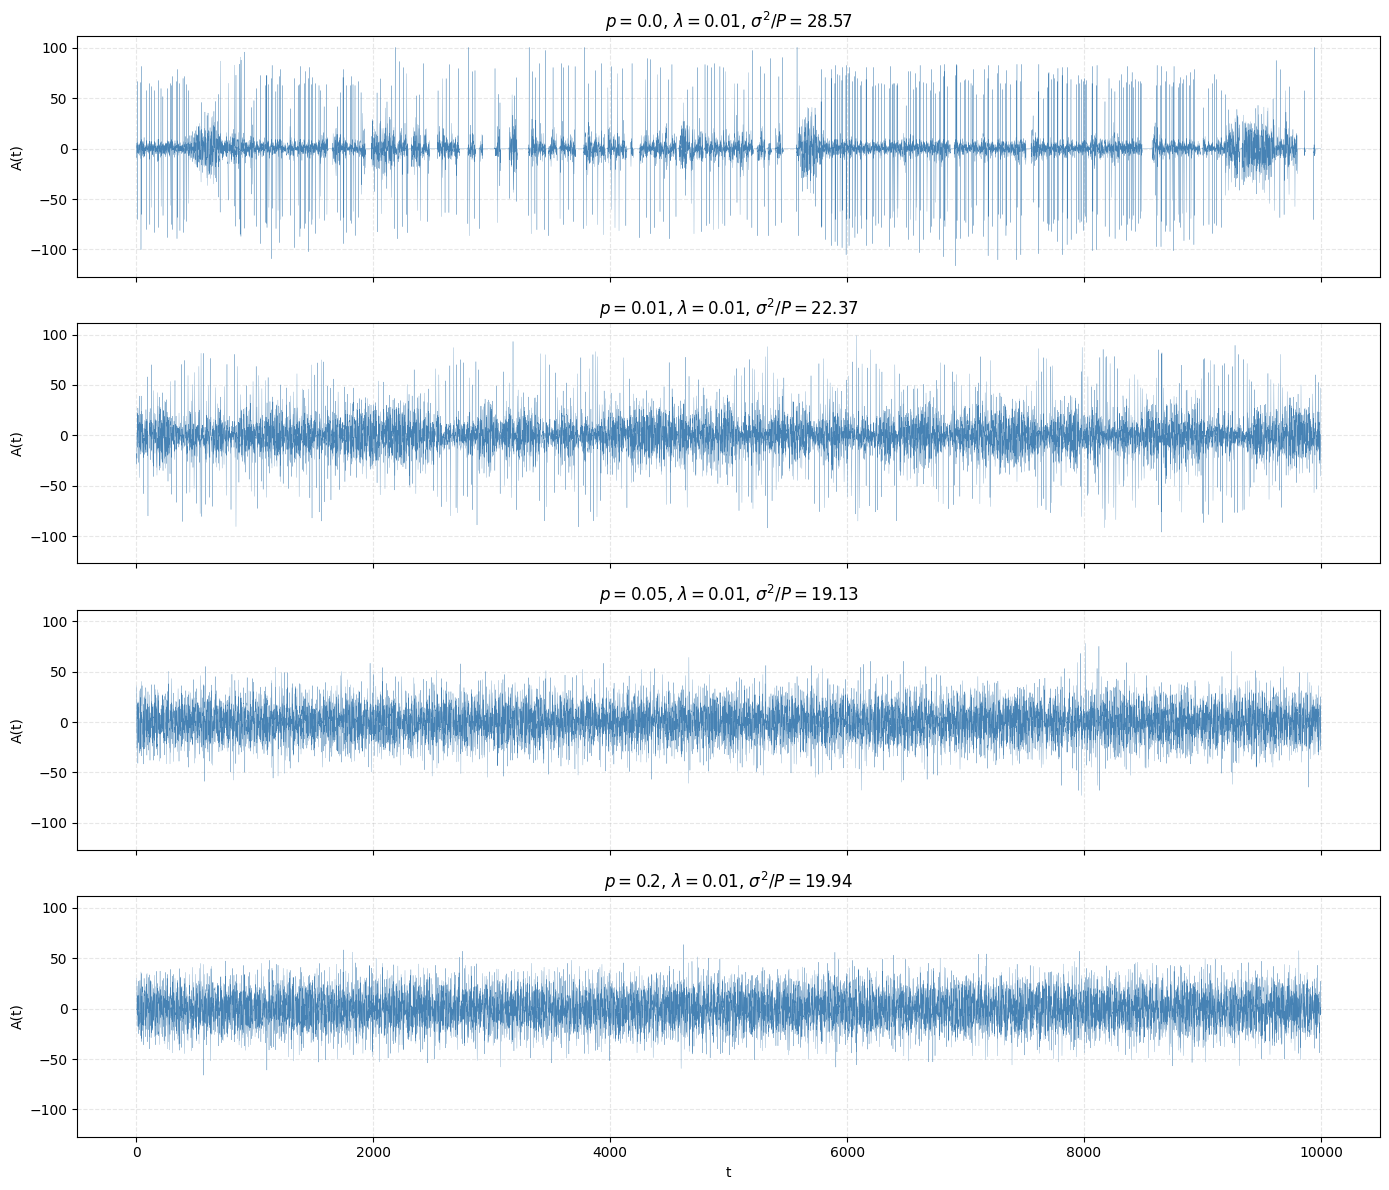

In [36]:
@njit
def _run_with_redraw(a, Omega, U, mu, P, epsilon, lam, p_redraw, T):
    N_s = a.shape[0]
    A_hist = np.empty(T)
    redraw_frac = np.empty(T)
    spec_gain = np.empty(T)
    prod_gain = np.empty(T)
    for t in range(T):
        n = (U >= 0).astype(np.float64)
        A_t = Omega[mu] + np.sum(n * a[:, mu])
        A_hist[t] = A_t
        spec_gain[t] = -np.sum(n * a[:, mu]) * A_t
        prod_gain[t] = -Omega[mu] * A_t
        U[:] = (1 - lam) * U - a[:, mu] * A_t - epsilon
        mu = (2 * mu + int(A_t > 0)) % P
        count = 0
        for i in range(N_s):
            if n[i] == 0.0 and np.random.random() < p_redraw:
                for j in range(P):
                    a[i, j] = 2.0 * np.random.randint(0, 2) - 1.0
                U[i] = 0.0
                count += 1
        redraw_frac[t] = count / N_s
    return A_hist, U, mu, redraw_frac, spec_gain, prod_gain

P, N_p, N_s, epsilon, lam = 16, 16, 200, 0.01, 0.01
T_phase = int(200 * P / epsilon)
p_values = [0.0, 0.01, 0.05, 0.2]

fig, axes = plt.subplots(len(p_values), 1, figsize=(14, 3 * len(p_values)), sharex=True, sharey=True)

results = {}
for j, p_r in tqdm(enumerate(p_values), total=len(p_values)):
    np.random.seed(42)
    Omega = np.random.normal(0, np.sqrt(N_p), size=P)
    a = np.random.choice([-1, 1], size=(N_s, P)).astype(np.float64)
    U = np.zeros(N_s)
    mu = np.random.randint(0, P)

    _, U, mu, _, _, _ = _run_with_redraw(a, Omega, U, mu, P, epsilon, lam, p_r, T_phase)
    A_m, U, mu, rf, sg, pg = _run_with_redraw(a, Omega, U, mu, P, epsilon, lam, p_r, T_phase)

    results[p_r] = (A_m, rf, sg, pg)
    axes[j].plot(A_m[:10000], lw=0.2, color='steelblue')
    axes[j].set_ylabel('A(t)')
    axes[j].set_title(f'$p = {p_r}$, $\\lambda = {lam}$, $\\sigma^2/P = {np.mean(A_m**2)/P:.2f}$')
    axes[j].grid(True, linestyle='--', alpha=0.3)

axes[-1].set_xlabel('t')
plt.tight_layout()
plt.show()

<blockquote>

For $p = 0$ (no redraw), $A(t)$ exhibits strong intermittent bursts with $\sigma^2/P = 28.57$. We easily observe the volatility clustering: long quiescent periods alternate with episodes of large coordinated fluctuations.

As $p$ increases, the amplitude of the bursts decreases and the dynamics become more homogeneous. Inactive agents who redraw their strategy replace a correlated (and poorly-performing) strategy with a fresh random one. This breaks the herd behavior that builds up through the score dynamics, reducing the collective over-reaction when agents re-enter simultaneously.

For $p = 0.2$, the volatility slightly increases ($\sigma^2/P = 19.94$) compared to $p = 0.05$, suggesting that too-frequent redrawing prevents agents from learning at all, injecting noise into the strategy pool.

</blockquote>

(b) Tracez la proportion d’agents qui retirent une stratégie en fonction du temps. Commentez

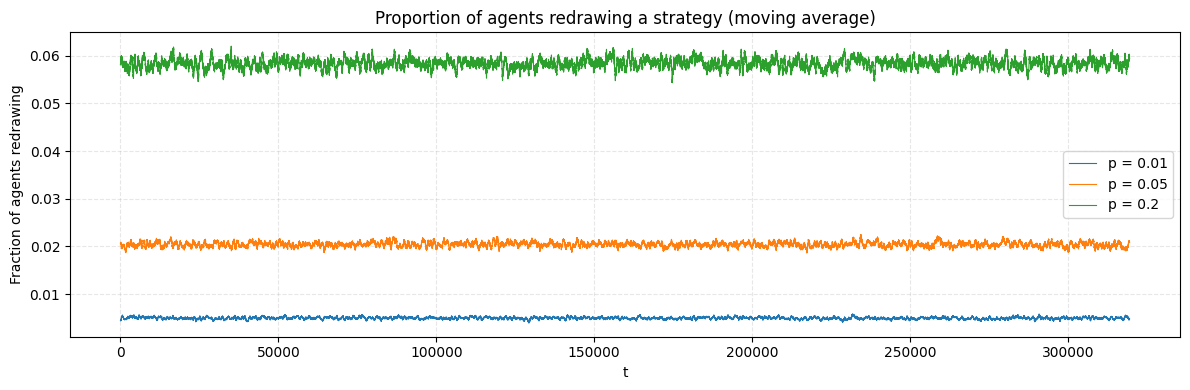

In [37]:
fig, ax = plt.subplots(figsize=(12, 4))
window = 500
for p_r in p_values:
    if p_r == 0: continue
    rf = results[p_r][1]
    rf_smooth = np.convolve(rf, np.ones(window)/window, mode='valid')
    ax.plot(rf_smooth, lw=0.8, label=f'p = {p_r}')

ax.set_xlabel('t')
ax.set_ylabel('Fraction of agents redrawing')
ax.set_title('Proportion of agents redrawing a strategy (moving average)')
ax.legend()
ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

<blockquote>

The fraction of agents redrawing is stationary for all values of $p$, confirming the system has reached a steady state. Since only inactive agents redraw, the actual redraw rate is $p \times f_{\text{inactive}}$, where $f_{\text{inactive}}$ is the fraction of agents with $U_i < 0$. 

For $p = 0.2$, $f_{\text{inactive}} \approx 0.06 / 0.2 = 0.3$, so roughly 30% of agents are inactive at any given time. The constancy over time indicates that the balance between agents exiting (due to losses) and re-entering (due to memory decay or redraw) has stabilized.

</blockquote>

(c) Est-ce que l’évolution des stratégies stabilise ou déstabilise le marché ?

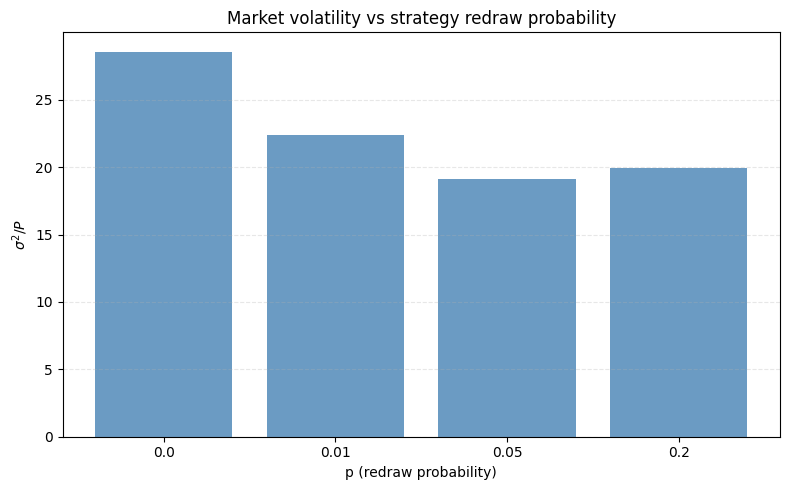

p=0.0: sigma^2/P = 28.568
p=0.01: sigma^2/P = 22.369
p=0.05: sigma^2/P = 19.131
p=0.2: sigma^2/P = 19.944


In [38]:
sigma2 = {p_r: np.mean(results[p_r][0]**2) / P for p_r in p_values}

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([str(p) for p in p_values], [sigma2[p] for p in p_values], color='steelblue', alpha=0.8)
ax.set_xlabel('p (redraw probability)')
ax.set_ylabel(r'$\sigma^2 / P$')
ax.set_title('Market volatility vs strategy redraw probability')
ax.grid(True, ls='--', alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

for p_r in p_values:
    print(f"p={p_r}: sigma^2/P = {sigma2[p_r]:.3f}")

<blockquote>

Strategy evolution stabilizes the market. $\sigma^2/P$ drops from $28.57$ at $p = 0$ to $\approx 19$ for $p \geq 0.05$, a reduction of about 33%. Redrawing injects diversity into the strategy pool: correlated strategies that collectively amplify $|A(t)|$ are replaced by uncorrelated random ones, reducing the crowding effect. The reduction saturates around $p \approx 0.05$, and further increases in $p$ give diminishing returns (or slight degradation), as agents lose the ability to learn and adapt before being reset.

</blockquote>

(d) Qui profite de l’évolution : les spéculateurs ou les producteurs ?

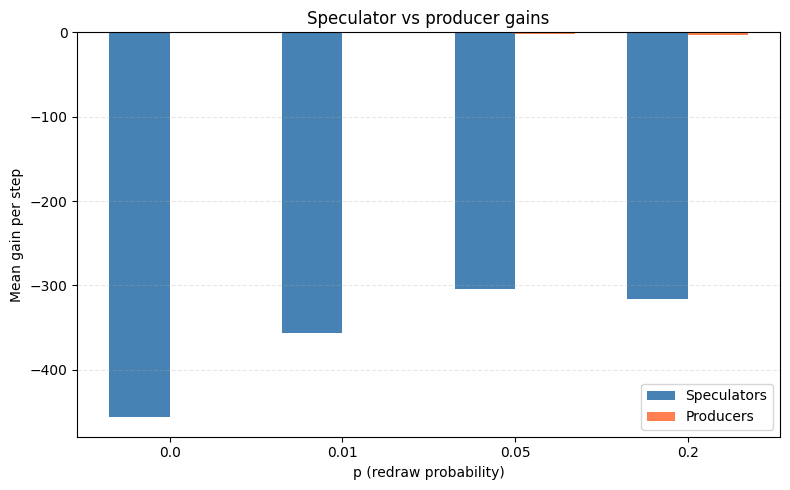

p=0.0: spec_gain=-456.540, prod_gain=-0.544
p=0.01: spec_gain=-356.680, prod_gain=-1.216
p=0.05: spec_gain=-304.286, prod_gain=-1.816
p=0.2: spec_gain=-316.463, prod_gain=-2.646


In [39]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(p_values))
w = 0.35
spec_gains = [np.mean(results[p][2]) for p in p_values]
prod_gains = [np.mean(results[p][3]) for p in p_values]

ax.bar(x - w/2, spec_gains, w, label='Speculators', color='steelblue')
ax.bar(x + w/2, prod_gains, w, label='Producers', color='coral')
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in p_values])
ax.set_xlabel('p (redraw probability)')
ax.set_ylabel('Mean gain per step')
ax.set_title('Speculator vs producer gains')
ax.legend()
ax.grid(True, ls='--', alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

for p_r in p_values:
    print(f"p={p_r}: spec_gain={np.mean(results[p_r][2]):.3f}, prod_gain={np.mean(results[p_r][3]):.3f}")

<blockquote>

Both speculators and producers have negative mean gains, consistent with the zero-sum identity $g_\text{spec} + g_\text{prod} = -\langle A^2 \rangle \leq 0$. The total market loss is shared between them.

Producer gain $g_\text{prod} = - \langle \Omega^\mu A \rangle = - N_p - \langle \Omega^\mu S \rangle$ is bounded above by $-N_p = -16$: producers bear an irreducible market-impact cost from their own exogenous flow, regardless of speculator behaviour.

Speculators benefit most from strategy evolution: their collective loss decreases by $\sim 30\%$ as $p$ goes from $0$ to $0.05$, tracking the drop in $\sigma^2/P$. Producer losses also decrease (since $|A|$ shrinks), but the improvement is smaller in absolute terms because the $-N_p$ floor dominates their budget.

This reflects the asymmetry of the model: producers must trade unconditionally and cannot adapt. Speculators, by refreshing strategies, partially escape the crowding trap and reduce the fraction of steps where they land in the majority.

</blockquote>